<a href="https://colab.research.google.com/github/cdenizbegec/DSA-210-Istanbul-s-Traffic/blob/main/TrafficIndexProject.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

##  1. We start by merging and processing our datasets

In [13]:
import pandas as pd

# 1. Load the files
# Note: We skip the first 3 rows of the weather file because they contain metadata
weather_df = pd.read_csv('open-meteo-41.02N29.02E36m (4).csv', skiprows=3)
traffic_df = pd.read_csv('traffic_index.csv')

# 2. Convert date columns to standard datetime objects
weather_df['date'] = pd.to_datetime(weather_df['time'])

# Traffic data cleaning
traffic_df['date_str'] = traffic_df['trafficindexdate'].astype(str).str[:10]
traffic_df['date'] = pd.to_datetime(traffic_df['date_str'])
traffic_df.drop(columns=['date_str'], inplace=True)

# 3. Date (2018 - 2024)
# We now use the maximum overlapping period available in both files.
start_date = '2018-01-01'
end_date = '2024-10-18'

print(f"Filtering data from {start_date} to {end_date}...")

weather_filtered = weather_df[(weather_df['date'] >= start_date) & (weather_df['date'] <= end_date)]
traffic_filtered = traffic_df[(traffic_df['date'] >= start_date) & (traffic_df['date'] <= end_date)]

# 4. Merge the data on the 'date' column
merged_df = pd.merge(weather_filtered, traffic_filtered, on='date', how='inner')

# 5. Clean up unnecessary columns
merged_df = merged_df.drop(columns=['time', 'trafficindexdate'], errors='ignore')

# 6. Save the final file
merged_df.to_csv('istanbul_weather_traffic_merged.csv', index=False)

print("Success! File 'istanbul_weather_traffic_merged.csv' has been created.")
print(f"Total rows: {len(merged_df)}")

Filtering data from 2018-01-01 to 2024-10-18...
Success! File 'istanbul_weather_traffic_merged.csv' has been created.
Total rows: 2482


# 2. Hyphothesis Testing and Data Visualization

           HYPOTHESIS TESTING RESULTS           
[1] Precipitation (Wet vs Dry)
    Mean Traffic (Wet): 28.78
    Mean Traffic (Dry): 26.77
    P-Value: 0.0000000024 -> Significant
--------------------------------------------------
[2] Rain (Rain vs No Rain)
    P-Value: 0.0000000020 -> Significant
--------------------------------------------------
[3] Snow (Snow vs No Snow)
    Mean Traffic (Snowy): 29.94
    P-Value: 0.0420347939 -> Significant
--------------------------------------------------
[4] Temperature (Hot vs Cold)
    Median Temp: 15.4°C
    Mean Traffic (Hot):  26.91
    Mean Traffic (Cold): 28.53
    P-Value: 0.0000014032 -> Significant
--------------------------------------------------
[5] Wind Speed (High vs Low)
    P-Value: 0.1151104800 -> Not Significant


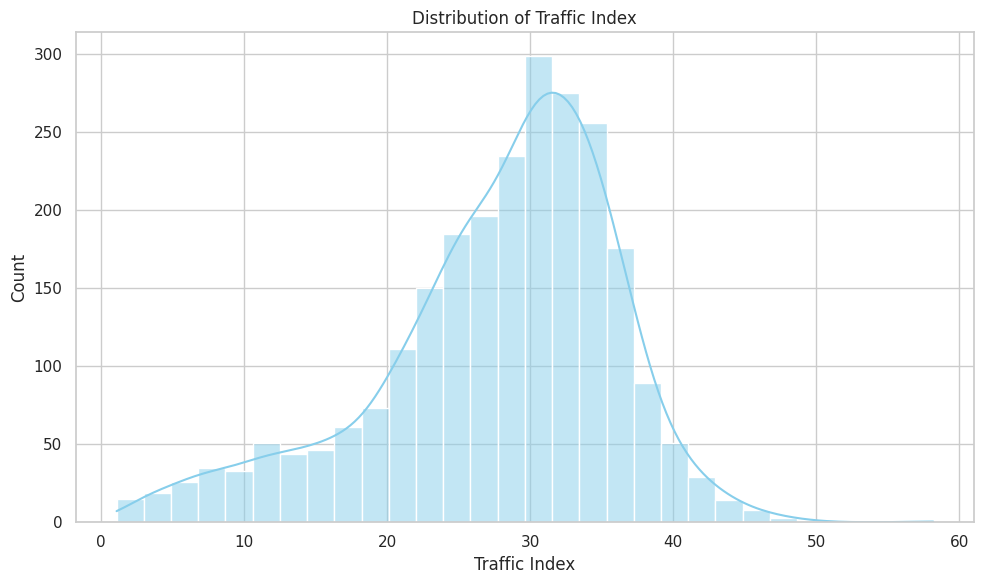

/tmp/ipython-input-1902708382.py:101: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='DayType', y='Traffic', data=df, palette='Set2')


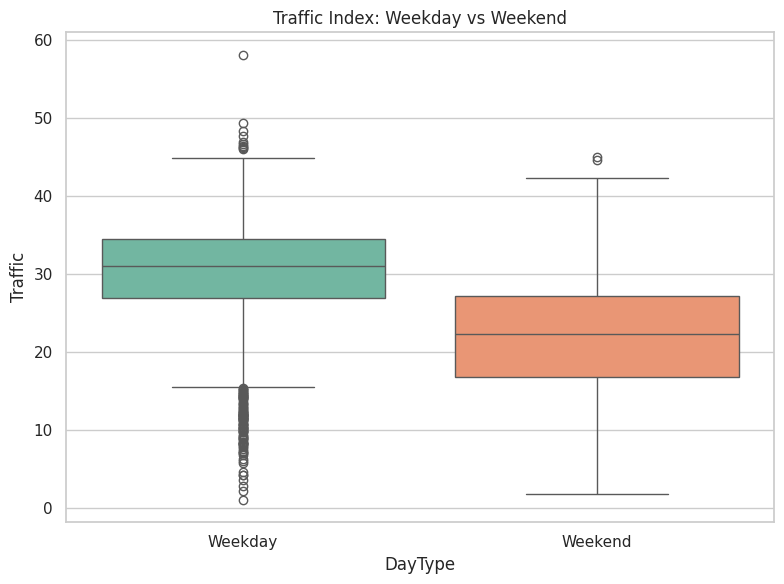

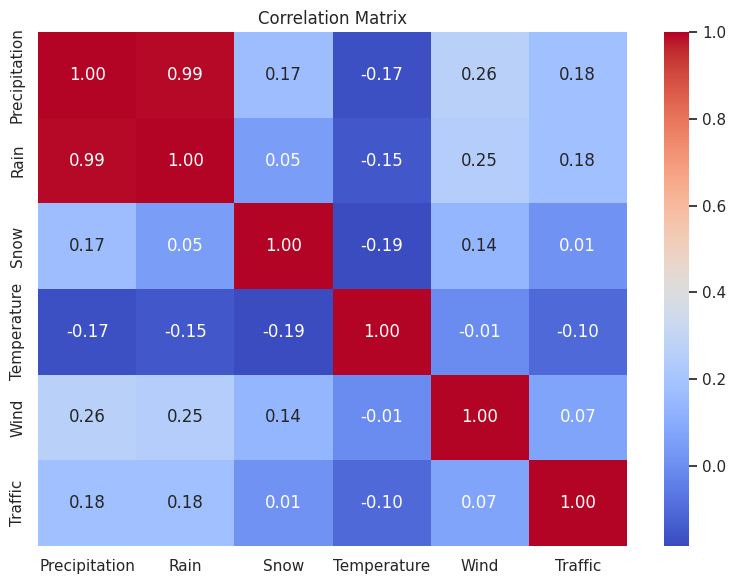

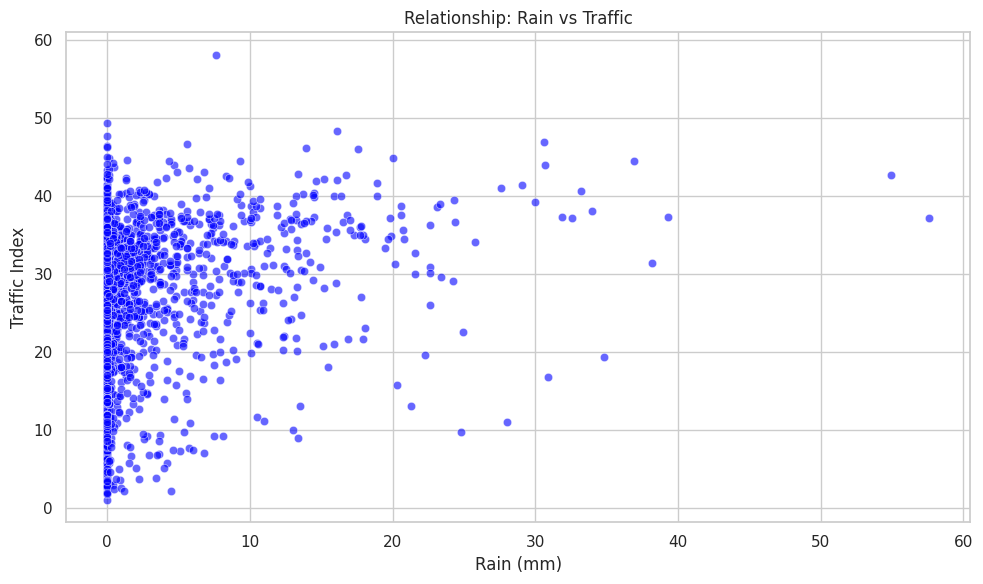

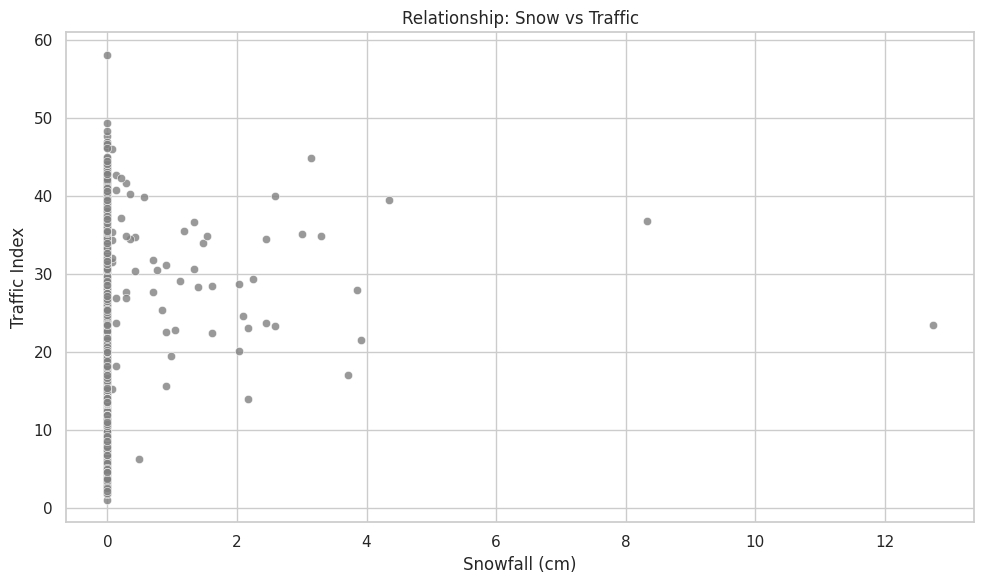

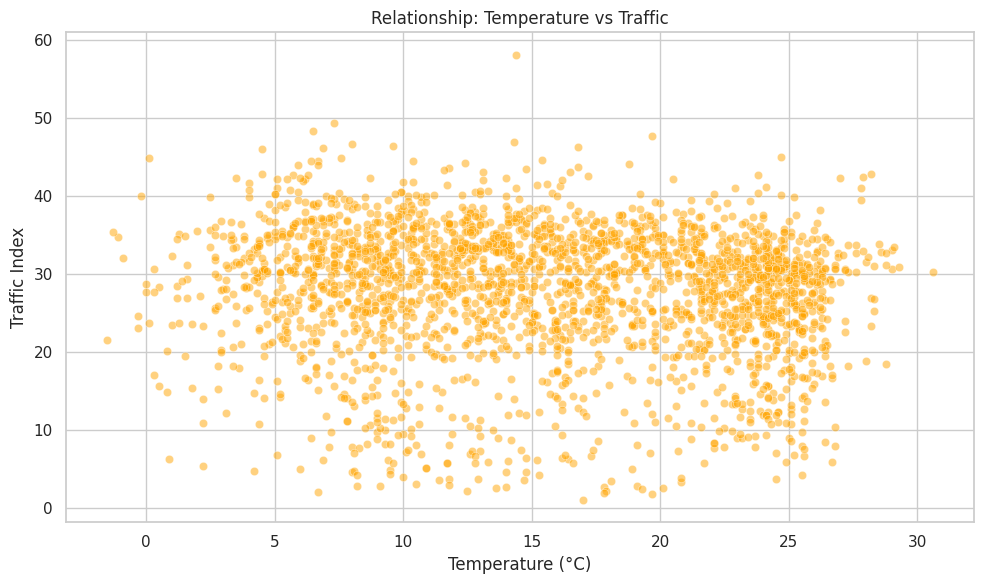

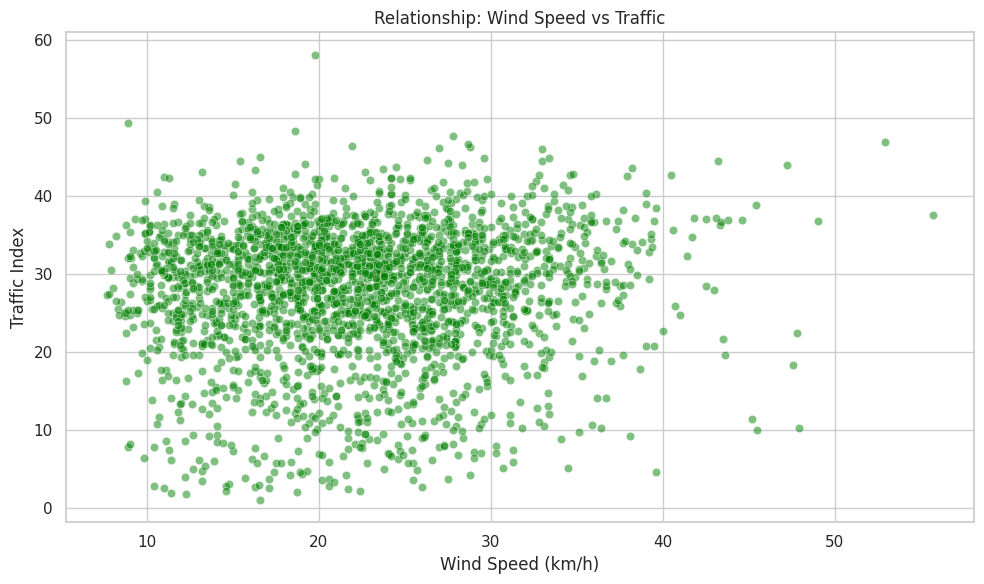

In [16]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from scipy import stats

def run_part2_analysis():
    # 1. Load the merged data created in Part 1
    try:
        df = pd.read_csv('istanbul_weather_traffic_merged.csv')
    except FileNotFoundError:
        print("Error: Please run Part 1 first to generate 'istanbul_weather_traffic_merged.csv'.")
        return

    # 2. Rename columns for cleaner analysis and plotting
    df.rename(columns={
        'precipitation_sum (mm)': 'Precipitation',
        'rain_sum (mm)': 'Rain',
        'snowfall_sum (cm)': 'Snow',
        'temperature_2m_mean (°C)': 'Temperature',
        'wind_speed_10m_max (km/h)': 'Wind',
        'average_traffic_index': 'Traffic'
    }, inplace=True)

    # Add 'DayType' for Weekend vs Weekday analysis
    df['date'] = pd.to_datetime(df['date'])
    df['DayType'] = df['date'].dt.dayofweek.apply(lambda x: 'Weekend' if x >= 5 else 'Weekday')

    # ---------------------------------------------------------
    # SECTION 3: HYPOTHESIS TESTING
    # ---------------------------------------------------------
    print("="*50)
    print("           HYPOTHESIS TESTING RESULTS           ")
    print("="*50)

    # Test 1: Precipitation (Wet vs Dry Days)
    wet = df[df['Precipitation'] > 0]['Traffic']
    dry = df[df['Precipitation'] == 0]['Traffic']
    t_stat, p_val = stats.ttest_ind(wet, dry, equal_var=False)
    print(f"[1] Precipitation (Wet vs Dry)")
    print(f"    Mean Traffic (Wet): {wet.mean():.2f}")
    print(f"    Mean Traffic (Dry): {dry.mean():.2f}")
    print(f"    P-Value: {p_val:.10f} -> {'Significant' if p_val < 0.05 else 'Not Significant'}")
    print("-" * 50)

    # Test 2: Rain (Rainy vs No Rain)
    rainy = df[df['Rain'] > 0]['Traffic']
    no_rain = df[df['Rain'] == 0]['Traffic']
    t_stat, p_val = stats.ttest_ind(rainy, no_rain, equal_var=False)
    print(f"[2] Rain (Rain vs No Rain)")
    print(f"    P-Value: {p_val:.10f} -> {'Significant' if p_val < 0.05 else 'Not Significant'}")
    print("-" * 50)

    # Test 3: Snow (Snowy vs No Snow)
    snowy = df[df['Snow'] > 0]['Traffic']
    no_snow = df[df['Snow'] == 0]['Traffic']
    if len(snowy) > 1:
        t_stat, p_val = stats.ttest_ind(snowy, no_snow, equal_var=False)
        print(f"[3] Snow (Snow vs No Snow)")
        print(f"    Mean Traffic (Snowy): {snowy.mean():.2f}")
        print(f"    P-Value: {p_val:.10f} -> {'Significant' if p_val < 0.05 else 'Not Significant'}")
    else:
        print("[3] Snow: Not enough snowy days for testing.")
    print("-" * 50)

    # Test 4: Temperature (Hot vs Cold - Split by Median)
    median_temp = df['Temperature'].median()
    hot_days = df[df['Temperature'] > median_temp]['Traffic']
    cold_days = df[df['Temperature'] <= median_temp]['Traffic']
    t_stat, p_val = stats.ttest_ind(hot_days, cold_days, equal_var=False)
    print(f"[4] Temperature (Hot vs Cold)")
    print(f"    Median Temp: {median_temp:.1f}°C")
    print(f"    Mean Traffic (Hot):  {hot_days.mean():.2f}")
    print(f"    Mean Traffic (Cold): {cold_days.mean():.2f}")
    print(f"    P-Value: {p_val:.10f} -> {'Significant' if p_val < 0.05 else 'Not Significant'}")
    print("-" * 50)

    # Test 5: Wind (High vs Low Wind - Split by Median)
    median_wind = df['Wind'].median()
    high_wind = df[df['Wind'] > median_wind]['Traffic']
    low_wind = df[df['Wind'] <= median_wind]['Traffic']
    t_stat, p_val = stats.ttest_ind(high_wind, low_wind, equal_var=False)
    print(f"[5] Wind Speed (High vs Low)")
    print(f"    P-Value: {p_val:.10f} -> {'Significant' if p_val < 0.05 else 'Not Significant'}")
    print("=" * 50)

    # ---------------------------------------------------------
    # SECTION 4: VISUALIZATION
    # ---------------------------------------------------------
    sns.set_theme(style="whitegrid")

    # Graph 1: General Traffic Distribution
    plt.figure(figsize=(10, 6))
    sns.histplot(df['Traffic'], bins=30, kde=True, color='skyblue')
    plt.title('Distribution of Traffic Index')
    plt.xlabel('Traffic Index')
    plt.tight_layout()
    plt.show()

    # Graph 2: Weekday vs Weekend (Boxplot)
    plt.figure(figsize=(8, 6))
    sns.boxplot(x='DayType', y='Traffic', data=df, palette='Set2')
    plt.title('Traffic Index: Weekday vs Weekend')
    plt.tight_layout()
    plt.show()

    # Graph 3: Correlation Matrix
    plt.figure(figsize=(8, 6))
    numeric_cols = ['Precipitation', 'Rain', 'Snow', 'Temperature', 'Wind', 'Traffic']
    cols_to_plot = [c for c in numeric_cols if c in df.columns]
    sns.heatmap(df[cols_to_plot].corr(), annot=True, cmap='coolwarm', fmt=".2f")
    plt.title('Correlation Matrix')
    plt.tight_layout()
    plt.show()

    # --- SPECIFIC WEATHER SCATTER PLOTS ---

    # Graph 4: Rain vs Traffic
    plt.figure(figsize=(10, 6))
    sns.scatterplot(x='Rain', y='Traffic', data=df, alpha=0.6, color='blue')
    plt.title('Relationship: Rain vs Traffic')
    plt.xlabel('Rain (mm)')
    plt.ylabel('Traffic Index')
    plt.tight_layout()
    plt.show()

    # Graph 5: Snow vs Traffic
    plt.figure(figsize=(10, 6))
    sns.scatterplot(x='Snow', y='Traffic', data=df, alpha=0.8, color='gray')
    plt.title('Relationship: Snow vs Traffic')
    plt.xlabel('Snowfall (cm)')
    plt.ylabel('Traffic Index')
    plt.tight_layout()
    plt.show()

    # Graph 6: Temperature vs Traffic 
    plt.figure(figsize=(10, 6))
    sns.scatterplot(x='Temperature', y='Traffic', data=df, alpha=0.5, color='orange')
    plt.title('Relationship: Temperature vs Traffic')
    plt.xlabel('Temperature (°C)')
    plt.ylabel('Traffic Index')
    plt.tight_layout()
    plt.show()

    # Graph 7: Wind vs Traffic
    plt.figure(figsize=(10, 6))
    sns.scatterplot(x='Wind', y='Traffic', data=df, alpha=0.5, color='green')
    plt.title('Relationship: Wind Speed vs Traffic')
    plt.xlabel('Wind Speed (km/h)')
    plt.ylabel('Traffic Index')
    plt.tight_layout()
    plt.show()

if __name__ == "__main__":
    run_part2_analysis()

# 3. Applying Machine Learning Methods

--------------------------------------------------
Data Split Summary
Training Samples: 1985
Testing Samples:  497
--------------------------------------------------
Model                | R2 Score     | RMSE        
--------------------------------------------------
Linear Regression    | -0.18240      | 7.79668
Random Forest        | -0.05326      | 7.35863
--------------------------------------------------


/tmp/ipython-input-4018512546.py:80: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=importances[indices], y=[features[i] for i in indices], palette="viridis")


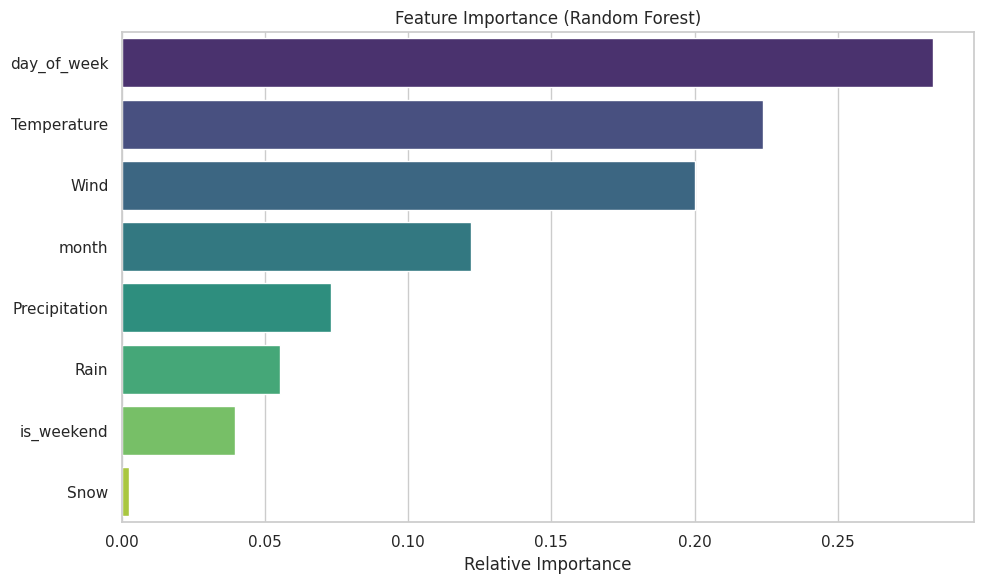

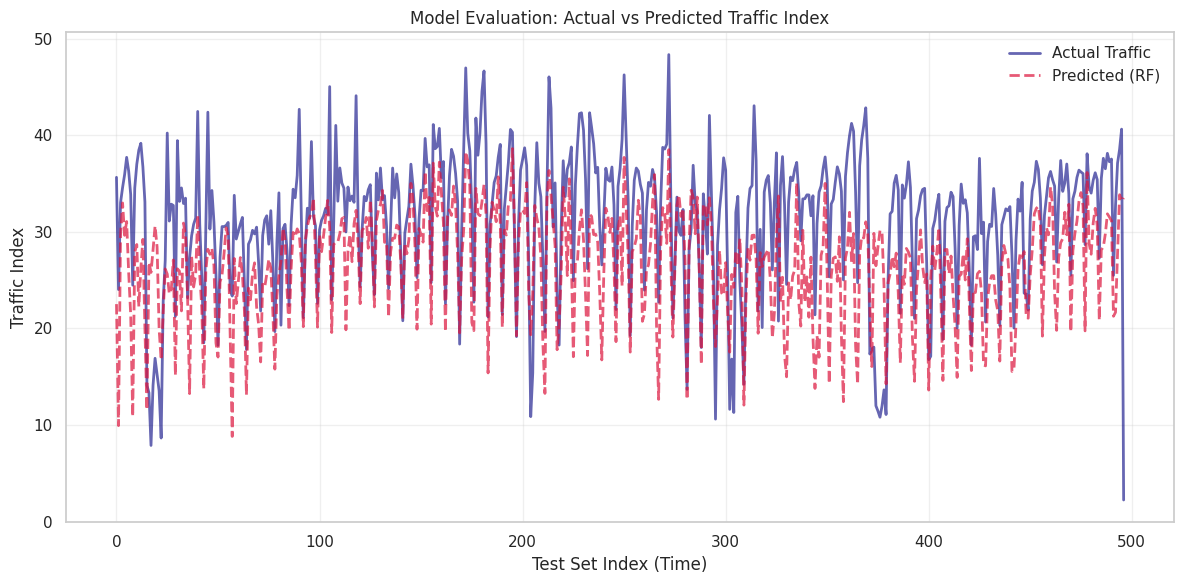

In [17]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error, r2_score

def run_ml_pipeline():
    # Load processed data
    try:
        df = pd.read_csv('istanbul_weather_traffic_merged.csv')
    except FileNotFoundError:
        print("Error: Dataset not found. Please run the previous scripts first.")
        return

    # Preprocessing
    df.rename(columns={
        'precipitation_sum (mm)': 'Precipitation',
        'rain_sum (mm)': 'Rain',
        'snowfall_sum (cm)': 'Snow',
        'temperature_2m_mean (°C)': 'Temperature',
        'wind_speed_10m_max (km/h)': 'Wind',
        'average_traffic_index': 'Traffic'
    }, inplace=True)

    df['date'] = pd.to_datetime(df['date'])

    # Feature Engineering
    df['day_of_week'] = df['date'].dt.dayofweek
    df['is_weekend'] = (df['day_of_week'] >= 5).astype(int)
    df['month'] = df['date'].dt.month

    # Define Feature Matrix (X) and Target Vector (y)
    features = ['Precipitation', 'Rain', 'Snow', 'Temperature', 'Wind', 'day_of_week', 'is_weekend', 'month']
    target = 'Traffic'

    X = df[features]
    y = df[target]

    # Train-Test Split (Time Series: Shuffle=False)
    X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, shuffle=False)

    print("-" * 50)
    print(f"Data Split Summary")
    print(f"Training Samples: {len(X_train)}")
    print(f"Testing Samples:  {len(X_test)}")
    print("-" * 50)

    # 1. Linear Regression
    lr = LinearRegression()
    lr.fit(X_train, y_train)
    lr_pred = lr.predict(X_test)

    lr_r2 = r2_score(y_test, lr_pred)
    lr_rmse = np.sqrt(mean_squared_error(y_test, lr_pred))

    # 2. Random Forest Regressor
    rf = RandomForestRegressor(n_estimators=100, random_state=42)
    rf.fit(X_train, y_train)
    rf_pred = rf.predict(X_test)

    rf_r2 = r2_score(y_test, rf_pred)
    rf_rmse = np.sqrt(mean_squared_error(y_test, rf_pred))

    # Output Metrics
    print(f"{'Model':<20} | {'R2 Score':<12} | {'RMSE':<12}")
    print("-" * 50)
    print(f"{'Linear Regression':<20} | {lr_r2:.5f}      | {lr_rmse:.5f}")
    print(f"{'Random Forest':<20} | {rf_r2:.5f}      | {rf_rmse:.5f}")
    print("-" * 50)

    # Visualization 1: Feature Importance
    plt.figure(figsize=(10, 6))
    importances = rf.feature_importances_
    indices = np.argsort(importances)[::-1]

    sns.barplot(x=importances[indices], y=[features[i] for i in indices], palette="viridis")
    plt.title('Feature Importance (Random Forest)')
    plt.xlabel('Relative Importance')
    plt.tight_layout()
    plt.savefig('ml_feature_importance.png')
    plt.show()

    # Visualization 2: Prediction vs Actual
    plt.figure(figsize=(12, 6))
    plt.plot(y_test.values, label='Actual Traffic', color='navy', alpha=0.6, linewidth=2)
    plt.plot(rf_pred, label='Predicted (RF)', color='crimson', alpha=0.7, linestyle='--', linewidth=2)

    plt.title('Model Evaluation: Actual vs Predicted Traffic Index')
    plt.xlabel('Test Set Index (Time)')
    plt.ylabel('Traffic Index')
    plt.legend()
    plt.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.savefig('ml_prediction_performance.png')
    plt.show()

if __name__ == "__main__":
    run_ml_pipeline()